In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("OnlineRetail.csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa3 in position 79780: invalid start byte

In [3]:
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=["CustomerID"])

In [9]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [13]:
(df["Quantity"] < 0).sum()

np.int64(8905)

In [14]:
df = df[df["Quantity"] > 0]

In [15]:
df.shape

(397924, 8)

In [16]:
(df["UnitPrice"] <= 0).sum()

np.int64(40)

In [17]:
df = df[df["UnitPrice"] > 0]

In [18]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [19]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
df["TotalAmount"].describe()

count    397884.000000
mean         22.397000
std         309.071041
min           0.001000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalAmount, dtype: float64

In [21]:
df["TotalAmount"].mean()

np.float64(22.396999889415003)

In [22]:

df.groupby("CustomerID")["InvoiceNo"].nunique().mean()

np.float64(4.272014753342554)

In [23]:
df.groupby("CustomerID")["TotalAmount"].sum().mean()

np.float64(2054.2664601198708)

In [24]:
df["CustomerID"].nunique()

4338

In [25]:
df["InvoiceDate"].min(), df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [26]:
reference_date = pd.Timestamp("2011-12-10")

In [27]:
recency = df.groupby("CustomerID")["InvoiceDate"].max().apply(
    lambda x: (reference_date - x).days
)

In [28]:
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()

In [29]:
monetary = df.groupby("CustomerID")["TotalAmount"].sum()

In [30]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

In [31]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,18,1,1757.55
12350.0,310,1,334.40


In [50]:
cluster_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "VIP Customers",
    3: "Loyal Customers"
}

rfm["Customer_Segment"] = rfm["Cluster"].map(cluster_names)

In [51]:
rfm[["Recency", "Frequency", "Monetary", "Customer_Segment"]].head(10)

,Recency,Frequency,Monetary,Customer_Segment
CustomerID,,,,
12346.0,325,1,77183.60,Loyal Customers
12347.0,2,7,4310.00,Regular Customers
12348.0,75,4,1797.24,Regular Customers
12349.0,18,1,1757.55,Regular Customers
12350.0,310,1,334.40,At-Risk Customers
12352.0,36,8,2506.04,Regular Customers
12353.0,204,1,89.00,At-Risk Customers
12354.0,232,1,1079.40,At-Risk Customers
12355.0,214,1,459.40,At-Risk Customers


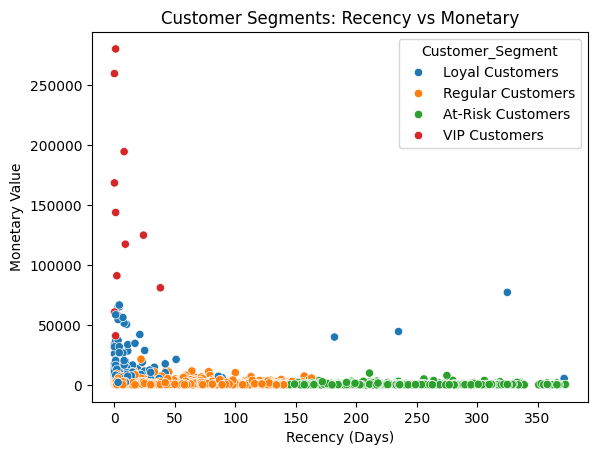

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Customer_Segment"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")
plt.show()

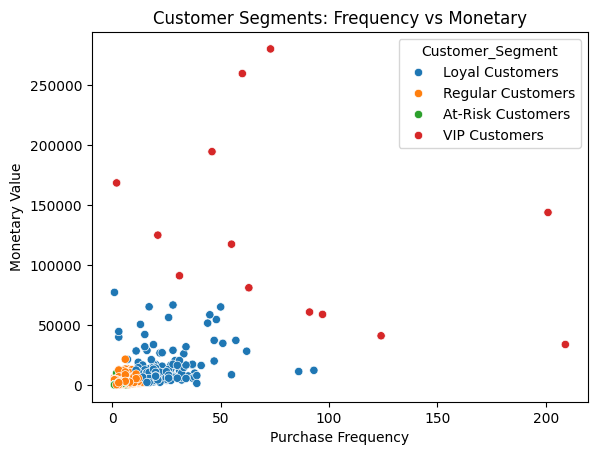

In [53]:
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Customer_Segment"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")
plt.show()

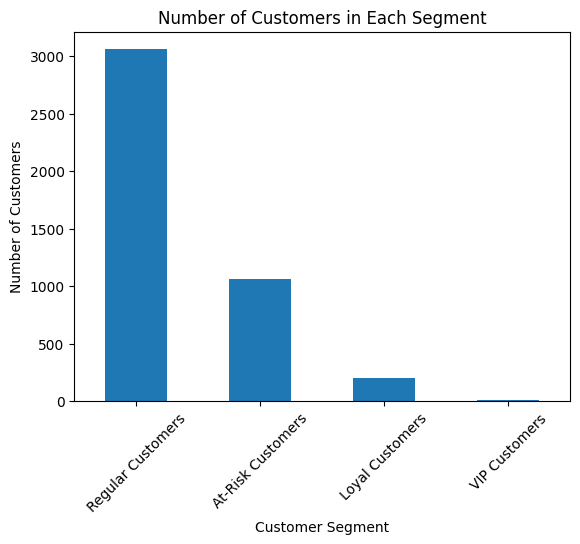

In [54]:
rfm["Customer_Segment"].value_counts().plot(
    kind="bar",
    title="Number of Customers in Each Segment"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

In [55]:
cluster_summary = rfm.groupby("Customer_Segment")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_summary

,Recency,Frequency,Monetary
Customer_Segment,,,
At-Risk Customers,248.17,1.55,478.19
Loyal Customers,14.96,22.33,12709.09
Regular Customers,43.43,3.68,1358.17
VIP Customers,6.62,82.54,127338.31


In [56]:
segment_percentage = (
    rfm["Customer_Segment"].value_counts(normalize=True) * 100
).round(2)

segment_percentage

Customer_Segment
Regular Customers    70.54
At-Risk Customers    24.46
Loyal Customers       4.70
VIP Customers         0.30
Name: proportion, dtype: float64

In [57]:
segment_percentage

Customer_Segment
Regular Customers    70.54
At-Risk Customers    24.46
Loyal Customers       4.70
VIP Customers         0.30
Name: proportion, dtype: float64

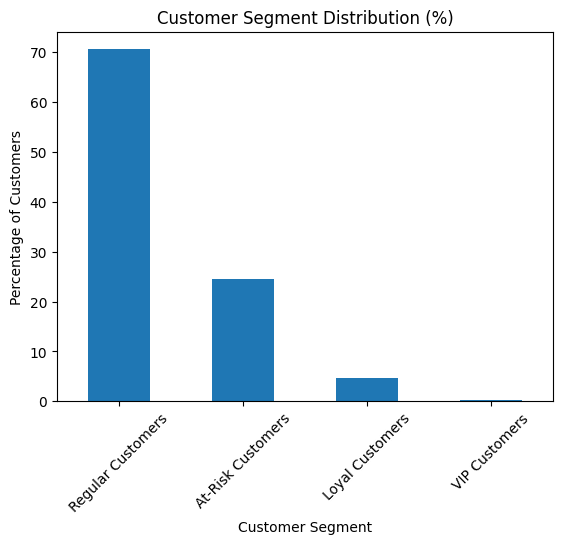

In [58]:
segment_percentage.plot(
    kind="bar",
    title="Customer Segment Distribution (%)"
)

plt.xlabel("Customer Segment")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=45)
plt.show()

In [59]:
marketing_actions = {
    "VIP Customers": "Reward with exclusive offers and loyalty benefits",
    "Loyal Customers": "Encourage repeat purchases with personalized promotions",
    "Regular Customers": "Use targeted offers to increase purchase frequency",
    "At-Risk Customers": "Send re-engagement offers and win-back campaigns"
}

marketing_actions

{'VIP Customers': 'Reward with exclusive offers and loyalty benefits',
 'Loyal Customers': 'Encourage repeat purchases with personalized promotions',
 'Regular Customers': 'Use targeted offers to increase purchase frequency',
 'At-Risk Customers': 'Send re-engagement offers and win-back campaigns'}

In [60]:
rfm.to_csv("Customer_Segmentation_Results.csv", index=True)

In [61]:
import os

os.path.exists("Customer_Segmentation_Results.csv")

True

In [62]:
insights = pd.DataFrame({
    "Customer Segment": [
        "VIP Customers",
        "Loyal Customers",
        "Regular Customers",
        "At-Risk Customers"
    ],
    "Key Insight": [
        "Highest frequency and spending with very recent purchases",
        "Frequent purchases and high spending with recent activity",
        "Moderate purchase frequency and spending",
        "Low frequency and spending with long time since last purchase"
    ],
    "Marketing Action": [
        "Offer exclusive rewards and loyalty benefits",
        "Use personalized promotions to encourage repeat purchases",
        "Provide targeted offers to increase purchase frequency",
        "Run re-engagement and win-back campaigns"
    ]
})

insights

,Customer Segment,Key Insight,Marketing Action
0,VIP Customers,Highest frequency and spending with very recen...,Offer exclusive rewards and loyalty benefits
1,Loyal Customers,Frequent purchases and high spending with rece...,Use personalized promotions to encourage repea...
2,Regular Customers,Moderate purchase frequency and spending,Provide targeted offers to increase purchase f...
3,At-Risk Customers,Low frequency and spending with long time sinc...,Run re-engagement and win-back campaigns


In [63]:
print("CUSTOMER SEGMENTATION SUMMARY")
print("--------------------------------")
print(f"Total Customers: {rfm.shape[0]}")
print(f"Total Segments: {rfm['Customer_Segment'].nunique()}")
print("\nCustomer Segments:")
print(rfm["Customer_Segment"].value_counts())

CUSTOMER SEGMENTATION SUMMARY
--------------------------------
Total Customers: 4338
Total Segments: 4

Customer Segments:
Customer_Segment
Regular Customers    3060
At-Risk Customers    1061
Loyal Customers       204
VIP Customers          13
Name: count, dtype: int64


In [64]:
rfm[["Recency", "Frequency", "Monetary"]].mean().round(2)

Recency        92.06
Frequency       4.27
Monetary     2054.27
dtype: float64

In [65]:
print("FINAL INSIGHTS")
print("--------------")
print("1. VIP Customers have the highest purchase frequency and monetary value.")
print("2. Loyal Customers show strong repeat purchasing and high spending.")
print("3. Regular Customers have moderate purchasing activity and spending.")
print("4. At-Risk Customers have low purchase frequency and long periods since their last purchase.")
print("5. Personalized marketing strategies can be used for each customer segment.")

FINAL INSIGHTS
--------------
1. VIP Customers have the highest purchase frequency and monetary value.
2. Loyal Customers show strong repeat purchasing and high spending.
3. Regular Customers have moderate purchasing activity and spending.
4. At-Risk Customers have low purchase frequency and long periods since their last purchase.
5. Personalized marketing strategies can be used for each customer segment.


In [66]:
print("Customer Segmentation Analysis completed successfully.")
print("Method: RFM Analysis + K-Means Clustering")
print("Number of Customer Segments: 4")
print("Segments: VIP, Loyal, Regular, At-Risk")
print("Marketing recommendations have been prepared for each segment.")

Customer Segmentation Analysis completed successfully.
Method: RFM Analysis + K-Means Clustering
Number of Customer Segments: 4
Segments: VIP, Loyal, Regular, At-Risk
Marketing recommendations have been prepared for each segment.


In [67]:
print("FINAL CHECK")
print("------------")
print("RFM Data Shape:", rfm.shape)
print("Clusters Created:", rfm["Cluster"].nunique())
print("Customer Segments:", rfm["Customer_Segment"].unique())
print("Results File Created:", os.path.exists("Customer_Segmentation_Results.csv"))

FINAL CHECK
------------
RFM Data Shape: (4338, 5)
Clusters Created: 4
Customer Segments: ['Loyal Customers' 'Regular Customers' 'At-Risk Customers' 'VIP Customers']
Results File Created: True
